In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [60]:
# Loading And Analyzing the DataSet 

df=pd.read_csv('../datasets/employee_career_promotion_practice.csv')
df.sample(2)

,Employee_ID,Age,Experience_Years,Monthly_Salary,Annual_Bonus,Performance_Score,Training_Hours,Projects_Completed,Job_Satisfaction,Education,Department,Employment_Type,Work_Mode,City,Promotion
795,EMP-00796,21.0,4.0,9979.51,10199.13,Good,29.5,3.0,High,Bachelor,Marketing,Full-Time,Hybrid,Karachi,No
1017,EMP-01018,26.0,4.0,12168.03,24760.26,Excellent,10.7,5.0,Very High,Master,IT,Full-Time,Remote,Lahore,No


In [71]:
df.shape # 1200 , 15 
df.isnull().sum()
df.info()
df.describe()
df['Promotion'].value_counts()



<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         1200 non-null   str    
 1   Age                 1190 non-null   float64
 2   Experience_Years    1188 non-null   float64
 3   Monthly_Salary      1185 non-null   float64
 4   Annual_Bonus        1187 non-null   float64
 5   Performance_Score   1190 non-null   str    
 6   Training_Hours      1188 non-null   float64
 7   Projects_Completed  1190 non-null   float64
 8   Job_Satisfaction    1191 non-null   str    
 9   Education           1192 non-null   str    
 10  Department          1192 non-null   str    
 11  Employment_Type     1193 non-null   str    
 12  Work_Mode           1193 non-null   str    
 13  City                1193 non-null   str    
 14  Promotion           1200 non-null   str    
dtypes: float64(6), str(9)
memory usage: 140.8 KB


Promotion
No     840
Yes    360
Name: count, dtype: int64

In [74]:
df.duplicated().sum()  # 0 duplicated Values 

(df.isnull().sum() / len(df)) * 100


Employee_ID           0.000000
Age                   0.833333
Experience_Years      1.000000
Monthly_Salary        1.250000
Annual_Bonus          1.083333
Performance_Score     0.833333
Training_Hours        1.000000
Projects_Completed    0.833333
Job_Satisfaction      0.750000
Education             0.666667
Department            0.666667
Employment_Type       0.583333
Work_Mode             0.583333
City                  0.583333
Promotion             0.000000
dtype: float64

In [83]:
categorical_cols = [
    'Education',
    'Performance_Score',
    'Job_Satisfaction',
    'Department',
    'Employment_Type',
    'Work_Mode',
    'City',
    'Promotion'
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())



Education
Education
Bachelor       571
Master         345
High School    189
PhD             87
Name: count, dtype: int64

Performance_Score
Performance_Score
Good         543
Average      392
Excellent    175
Poor          80
Name: count, dtype: int64

Job_Satisfaction
Job_Satisfaction
Medium       452
High         451
Very High    163
Low          125
Name: count, dtype: int64

Department
Department
Marketing     220
Finance       204
Operations    201
Sales         195
IT            189
HR            183
Name: count, dtype: int64

Employment_Type
Employment_Type
Full-Time    896
Contract     169
Part-Time    128
Name: count, dtype: int64

Work_Mode
Work_Mode
Office    555
Hybrid    456
Remote    182
Name: count, dtype: int64

City
City
Lahore        214
Multan        212
Karachi       211
Rawalpindi    195
Peshawar      186
Islamabad     175
Name: count, dtype: int64

Promotion
Promotion
No     840
Yes    360
Name: count, dtype: int64


In [84]:
df["Promotion"].value_counts(normalize=True) * 100

Promotion
No     70.0
Yes    30.0
Name: proportion, dtype: float64

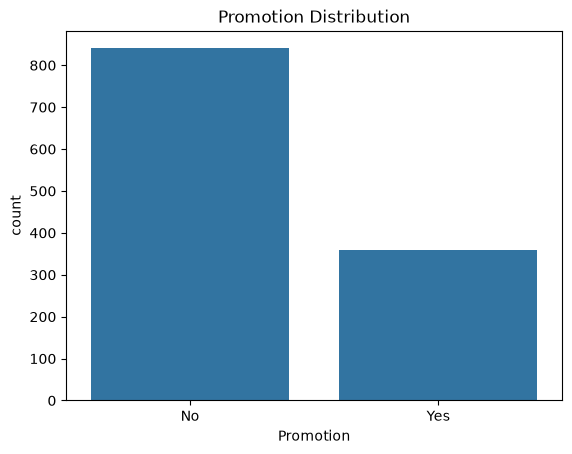

In [85]:
sns.countplot(data=df, x="Promotion")
plt.title("Promotion Distribution")
plt.show()

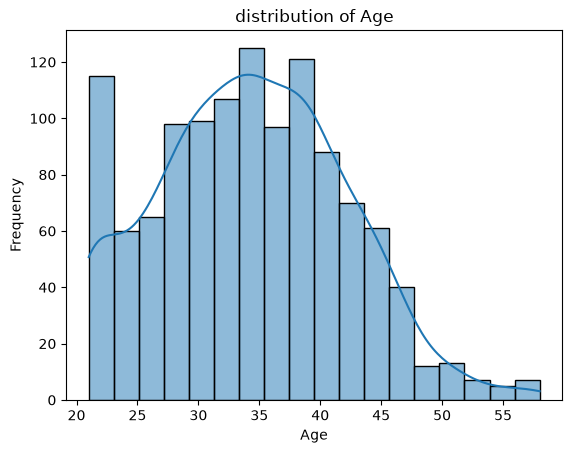

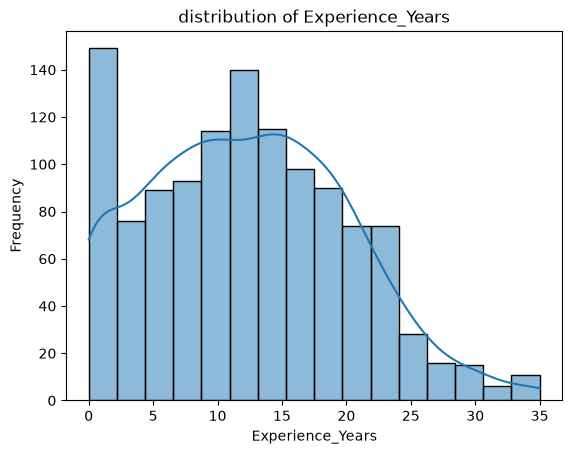

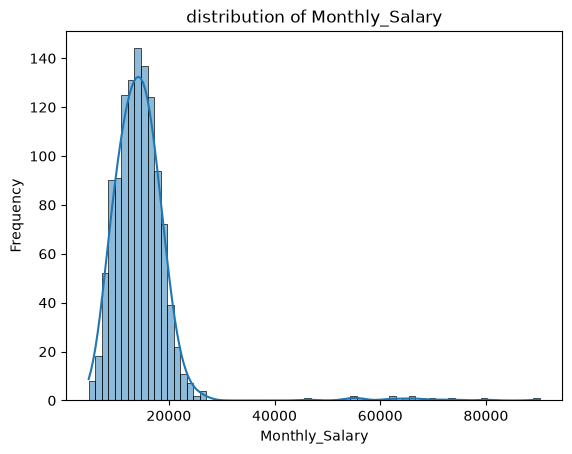

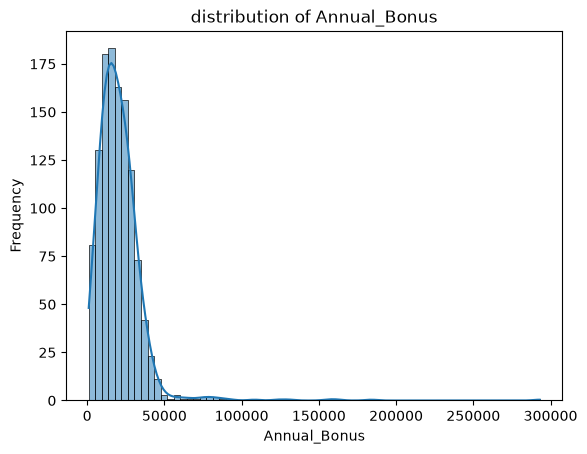

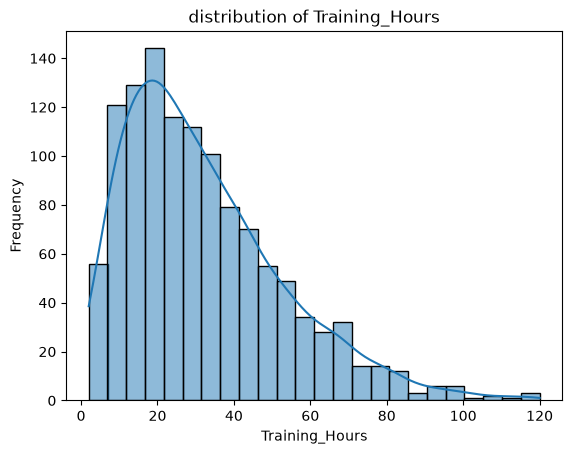

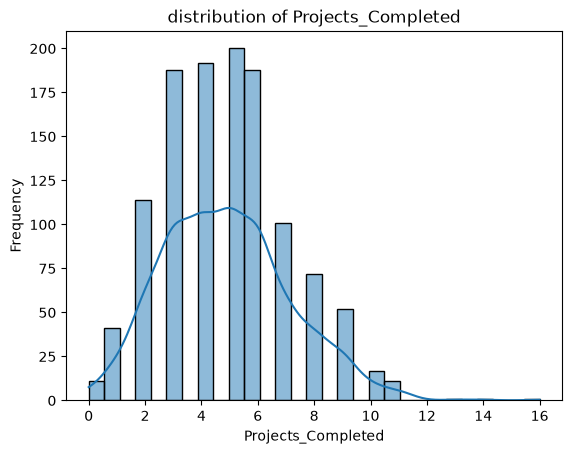

In [87]:
numerical_cols = [
    "Age",
    "Experience_Years",
    "Monthly_Salary",
    "Annual_Bonus",
    "Training_Hours",
    "Projects_Completed"
]

for value in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[value],kde=True)
    plt.title(f'distribution of {value}')
    plt.xlabel(value)
    plt.ylabel('Frequency')
    plt.show()

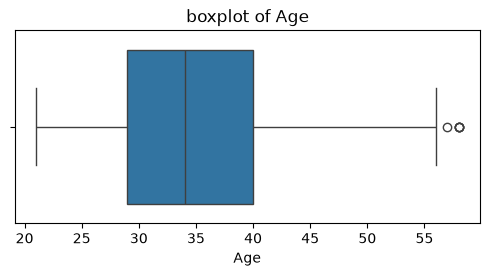

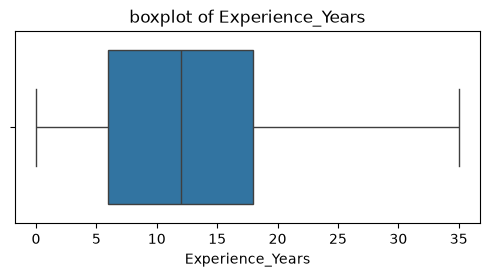

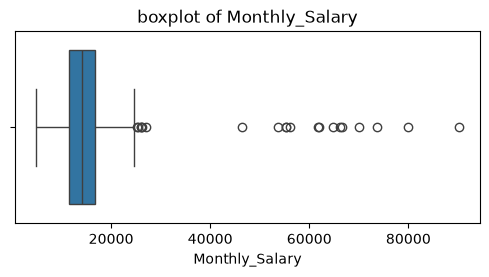

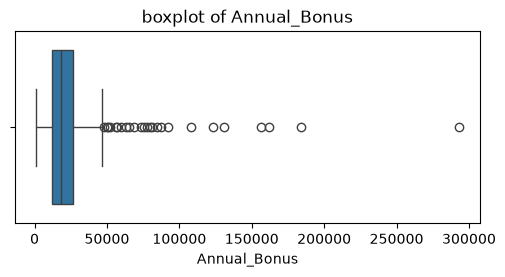

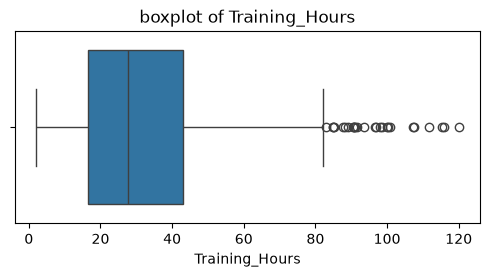

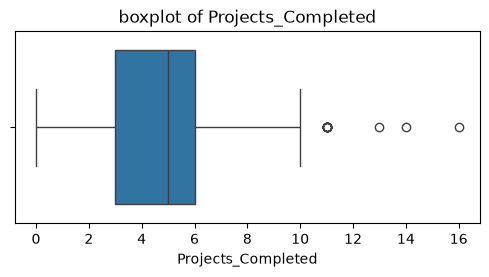

In [88]:

for cols in numerical_cols:
    plt.figure(figsize=(6,2.5))
    sns.boxplot(x=df[cols])
    plt.title(f'boxplot of {cols}')
    plt.show()

In [91]:
for col in numerical_cols:
    skew_value = df[col].skew()
    print(f"\nSkewness value of {col}:", skew_value)

    
    



Skewness value of Age: 0.1883889049974149

Skewness value of Experience_Years: 0.30895160623390006

Skewness value of Monthly_Salary: 5.455504227226875

Skewness value of Annual_Bonus: 6.442880808763048

Skewness value of Training_Hours: 1.065045406467709

Skewness value of Projects_Completed: 0.48819680601592597


--- Average Values (Promoted vs Not Promoted) ---
Promotion                     No           Yes
Age                    33.177671     36.988796
Experience_Years       11.048077     15.272472
Monthly_Salary      14044.607645  16315.665938
Annual_Bonus        19342.686835  23398.021039
Training_Hours         29.371049     38.277159
Projects_Completed      4.651079      5.435393


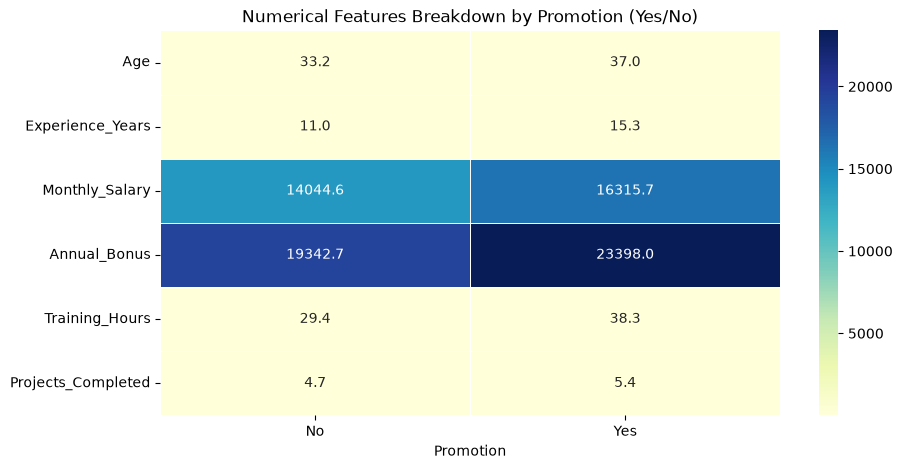

In [98]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


numerical_cols = [
    "Age", "Experience_Years", "Monthly_Salary", 
    "Annual_Bonus", "Training_Hours", "Projects_Completed"
]


mean_summary = df.groupby('Promotion')[numerical_cols].mean().T
print("Average Values (Promoted vs Not Promoted) ---")
print(mean_summary)

plt.figure(figsize=(10, 5))
sns.heatmap(mean_summary, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5)
plt.title("Numerical Features Breakdown by Promotion (Yes/No)")
plt.show()

In [99]:
categorical_cols = [
    "Education",
    "Performance_Score",
    "Job_Satisfaction",
    "Department",
    "Employment_Type",
    "Work_Mode",
    "City"
]

for col in categorical_cols:
    data=df.groupby(col)['Promotion'].value_counts(normalize=True)*100
    print(data)

Education    Promotion
Bachelor     No           70.402802
             Yes          29.597198
High School  No           73.544974
             Yes          26.455026
Master       No           67.536232
             Yes          32.463768
PhD          No           70.114943
             Yes          29.885057
Name: proportion, dtype: float64
Performance_Score  Promotion
Average            No           81.887755
                   Yes          18.112245
Excellent          Yes          50.285714
                   No           49.714286
Good               No           64.825046
                   Yes          35.174954
Poor               No           92.500000
                   Yes           7.500000
Name: proportion, dtype: float64
Job_Satisfaction  Promotion
High              No           70.288248
                  Yes          29.711752
Low               No           71.200000
                  Yes          28.800000
Medium            No           70.796460
                  Yes    

In [100]:
# Correlation matrix
corr_matrix = df[numerical_cols].corr()

print(corr_matrix)

                         Age  Experience_Years  Monthly_Salary  Annual_Bonus  \
Age                 1.000000          0.928940        0.481640      0.288949   
Experience_Years    0.928940          1.000000        0.492369      0.261101   
Monthly_Salary      0.481640          0.492369        1.000000      0.545065   
Annual_Bonus        0.288949          0.261101        0.545065      1.000000   
Training_Hours      0.013829          0.008379        0.050093      0.027997   
Projects_Completed  0.008174          0.018480       -0.006860      0.019685   

                    Training_Hours  Projects_Completed  
Age                       0.013829            0.008174  
Experience_Years          0.008379            0.018480  
Monthly_Salary            0.050093           -0.006860  
Annual_Bonus              0.027997            0.019685  
Training_Hours            1.000000            0.063560  
Projects_Completed        0.063560            1.000000  


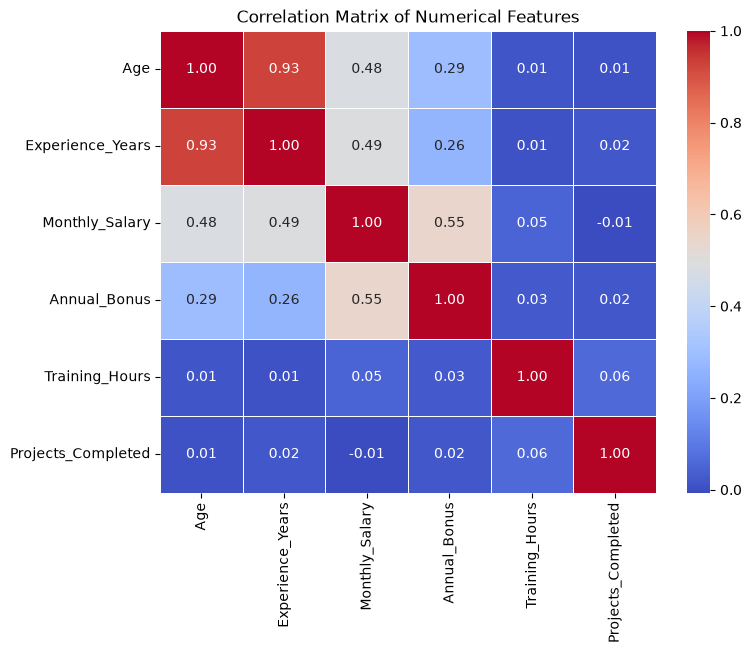

In [101]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [108]:
iqr_results = []

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    )

    outlier_count = outlier_mask.sum()
    outlier_percentage = (outlier_count / len(df)) * 100

    # Actual outlier values
    outlier_values = df.loc[outlier_mask, col].sort_values().to_list()
    print("\nOutlier Promotion Distribution:")
    print(
        df.loc[outlier_mask, 'Promotion']
        .value_counts(normalize=True) * 100
    )

    print("\nNormal Promotion Distribution:")
    print(
        df.loc[~outlier_mask, 'Promotion']
        .value_counts(normalize=True) * 100
    )

    iqr_results.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': outlier_count,
        'Outlier_Percentage': outlier_percentage,
        'Outlier_Values': outlier_values
    })

iqr_results = pd.DataFrame(iqr_results)
print(iqr_results["Outlier_Values"])

# print(iqr_results)


Outlier Promotion Distribution:
Promotion
Yes    60.0
No     40.0
Name: proportion, dtype: float64

Normal Promotion Distribution:
Promotion
No     70.125523
Yes    29.874477
Name: proportion, dtype: float64

Outlier Promotion Distribution:
Series([], Name: proportion, dtype: float64)

Normal Promotion Distribution:
Promotion
No     70.0
Yes    30.0
Name: proportion, dtype: float64

Outlier Promotion Distribution:
Promotion
Yes    50.0
No     50.0
Name: proportion, dtype: float64

Normal Promotion Distribution:
Promotion
No     70.338983
Yes    29.661017
Name: proportion, dtype: float64

Outlier Promotion Distribution:
Promotion
No     52.0
Yes    48.0
Name: proportion, dtype: float64

Normal Promotion Distribution:
Promotion
No     70.382979
Yes    29.617021
Name: proportion, dtype: float64

Outlier Promotion Distribution:
Promotion
No     53.846154
Yes    46.153846
Name: proportion, dtype: float64

Normal Promotion Distribution:
Promotion
No     70.357751
Yes    29.642249
Name: prop

In [ ]:
df.drop(columns=['Employee_ID']) 



,Age,Experience_Years,Monthly_Salary,Annual_Bonus,Performance_Score,Training_Hours,Projects_Completed,Job_Satisfaction,Education,Department,Employment_Type,Work_Mode,City,Promotion,Promotion_Num
0,36.0,15.0,12213.88,2442.75,Good,13.3,2.0,Medium,Bachelor,Sales,Full-Time,Office,Multan,No,0
1,21.0,5.0,9905.15,5509.05,Average,21.7,3.0,High,Master,IT,Full-Time,Hybrid,Islamabad,No,0
2,39.0,22.0,18764.54,29672.59,Average,13.6,8.0,Medium,Bachelor,Operations,Full-Time,Remote,Peshawar,Yes,1
3,43.0,15.0,14102.17,30851.54,Excellent,38.4,3.0,Low,Bachelor,Operations,Full-Time,Hybrid,Multan,No,0
4,42.0,17.0,17039.59,12473.48,Good,36.9,5.0,Medium,Master,Operations,Full-Time,Hybrid,Rawalpindi,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,32.0,15.0,16559.77,8637.33,Average,35.5,3.0,Medium,Bachelor,Operations,Full-Time,Office,Rawalpindi,No,0
1196,25.0,0.0,10041.21,19719.68,Good,4.9,4.0,High,Bachelor,Marketing,Full-Time,Office,Karachi,No,0
1197,32.0,13.0,14707.63,3791.06,Average,32.6,2.0,High,Master,Operations,Full-Time,Hybrid,Karachi,No,0
1198,31.0,11.0,14329.33,8975.28,Good,29.9,5.0,High,Master,Finance,Contract,Remote,Rawalpindi,Yes,1


In [114]:
from sklearn.model_selection import train_test_split

X=df.drop(columns='Promotion')
Y=df['Promotion']

x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=42,stratify=Y)
# print(x_train,x_test,y_train,y_test)

In [117]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler

skew_numerical_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('transformation',PowerTransformer(method='yeo-johnson')),
    ('Scaling',StandardScaler())
    
])

In [118]:
simple_numerical_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaling',StandardScaler())
])

In [119]:
ordinal_cols = [
    "Education",
    "Performance_Score",
    "Job_Satisfaction"
]

for col in ordinal_cols:
    print(f"\n{col}")
    print(df[col].unique())


Education
<StringArray>
['Bachelor', 'Master', 'High School', 'PhD', nan]
Length: 5, dtype: str

Performance_Score
<StringArray>
['Good', 'Average', 'Excellent', 'Poor', nan]
Length: 5, dtype: str

Job_Satisfaction
<StringArray>
['Medium', 'High', 'Low', 'Very High', nan]
Length: 5, dtype: str


In [120]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('ordinal_encoding', OrdinalEncoder(
        categories=[
            ['High School', 'Bachelor', 'Master', 'PhD'],
            ['Poor', 'Average', 'Good', 'Excellent'],
            ['Low', 'Medium', 'High', 'Very High']
        ]
    ))
])

In [121]:
from sklearn.preprocessing import OneHotEncoder
nominal_pipeline= Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('one_hot_encoding',OneHotEncoder( handle_unknown='ignore'))
])

In [122]:
# Columns For Pipelines
skewed_num_cols = [
    'Monthly_Salary',
    'Annual_Bonus'
]
simple_num_cols = [
    'Age',
    'Experience_Years',
    'Training_Hours',
    'Projects_Completed'
]
ordinal_cols = [
    'Education',
    'Performance_Score',
    'Job_Satisfaction'
]
nominal_cols = [
    'City',
    'Work_Mode',
    'Employment_Type',
    'Department'
]

In [124]:
from sklearn.compose import ColumnTransformer

preprocess_step=ColumnTransformer([
    ('skewed_num_data',skew_numerical_pipeline,skewed_num_cols),
    ('simple_num_data',simple_numerical_pipeline,simple_num_cols),
    ('ordinal_data',ordinal_pipeline,ordinal_cols),
    ('nominal_data',nominal_pipeline,nominal_cols)
])

In [125]:
from sklearn.linear_model import LogisticRegression
model=Pipeline([
    ('preprocess',preprocess_step),
    ('lgr',LogisticRegression(random_state=42))
])

In [126]:
model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('lgr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Employee_ID','Age','Experience_Years',...,'Work_Mode','City', 'Promotion_Num']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewed_num_data', ...), ('simple_num_data', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By sp

In [ ]:

y_prediction =model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

model_accuracy=accuracy_score(y_test,y_prediction)

print(f'model is {model_accuracy*100} %  Accurate ')

model is 71.11111111111111 %  Accurate 


In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [ ]:
# Loading And Analyzing the DataSet 

df=pd.read_csv('../datasets/employee_career_promotion_practice.csv')
df.sample(2)

,Employee_ID,Age,Experience_Years,Monthly_Salary,Annual_Bonus,Performance_Score,Training_Hours,Projects_Completed,Job_Satisfaction,Education,Department,Employment_Type,Work_Mode,City,Promotion
795,EMP-00796,21.0,4.0,9979.51,10199.13,Good,29.5,3.0,High,Bachelor,Marketing,Full-Time,Hybrid,Karachi,No
1017,EMP-01018,26.0,4.0,12168.03,24760.26,Excellent,10.7,5.0,Very High,Master,IT,Full-Time,Remote,Lahore,No


In [ ]:
df.shape # 1200 , 15 
df.isnull().sum()
df.info()
df.describe()
df['Promotion'].value_counts()



<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         1200 non-null   str    
 1   Age                 1190 non-null   float64
 2   Experience_Years    1188 non-null   float64
 3   Monthly_Salary      1185 non-null   float64
 4   Annual_Bonus        1187 non-null   float64
 5   Performance_Score   1190 non-null   str    
 6   Training_Hours      1188 non-null   float64
 7   Projects_Completed  1190 non-null   float64
 8   Job_Satisfaction    1191 non-null   str    
 9   Education           1192 non-null   str    
 10  Department          1192 non-null   str    
 11  Employment_Type     1193 non-null   str    
 12  Work_Mode           1193 non-null   str    
 13  City                1193 non-null   str    
 14  Promotion           1200 non-null   str    
dtypes: float64(6), str(9)
memory usage: 140.8 KB


Promotion
No     840
Yes    360
Name: count, dtype: int64

In [ ]:
df.duplicated().sum()  # 0 duplicated Values 

(df.isnull().sum() / len(df)) * 100


Employee_ID           0.000000
Age                   0.833333
Experience_Years      1.000000
Monthly_Salary        1.250000
Annual_Bonus          1.083333
Performance_Score     0.833333
Training_Hours        1.000000
Projects_Completed    0.833333
Job_Satisfaction      0.750000
Education             0.666667
Department            0.666667
Employment_Type       0.583333
Work_Mode             0.583333
City                  0.583333
Promotion             0.000000
dtype: float64

In [ ]:
categorical_cols = [
    'Education',
    'Performance_Score',
    'Job_Satisfaction',
    'Department',
    'Employment_Type',
    'Work_Mode',
    'City',
    'Promotion'
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())



Education
Education
Bachelor       571
Master         345
High School    189
PhD             87
Name: count, dtype: int64

Performance_Score
Performance_Score
Good         543
Average      392
Excellent    175
Poor          80
Name: count, dtype: int64

Job_Satisfaction
Job_Satisfaction
Medium       452
High         451
Very High    163
Low          125
Name: count, dtype: int64

Department
Department
Marketing     220
Finance       204
Operations    201
Sales         195
IT            189
HR            183
Name: count, dtype: int64

Employment_Type
Employment_Type
Full-Time    896
Contract     169
Part-Time    128
Name: count, dtype: int64

Work_Mode
Work_Mode
Office    555
Hybrid    456
Remote    182
Name: count, dtype: int64

City
City
Lahore        214
Multan        212
Karachi       211
Rawalpindi    195
Peshawar      186
Islamabad     175
Name: count, dtype: int64

Promotion
Promotion
No     840
Yes    360
Name: count, dtype: int64


In [ ]:
df["Promotion"].value_counts(normalize=True) * 100

Promotion
No     70.0
Yes    30.0
Name: proportion, dtype: float64

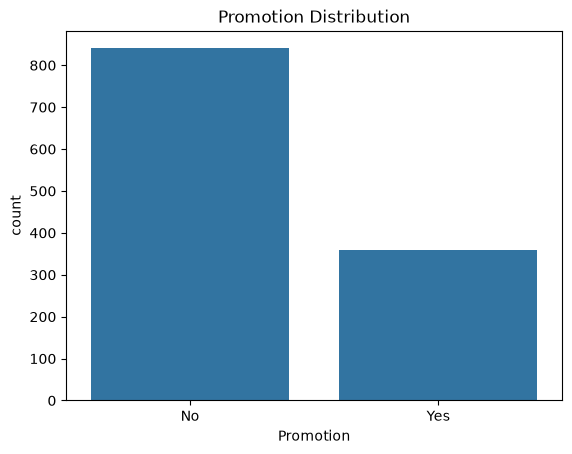

In [ ]:
sns.countplot(data=df, x="Promotion")
plt.title("Promotion Distribution")
plt.show()

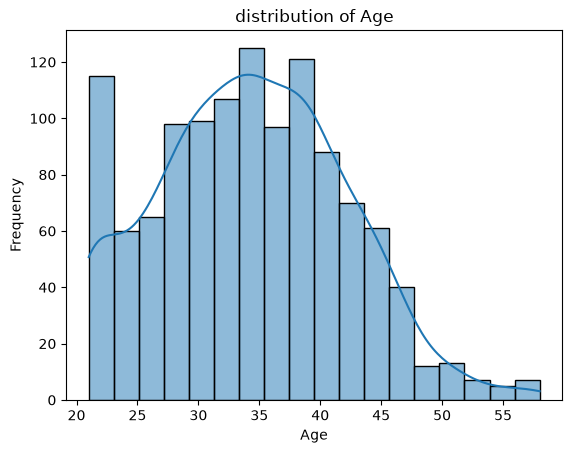

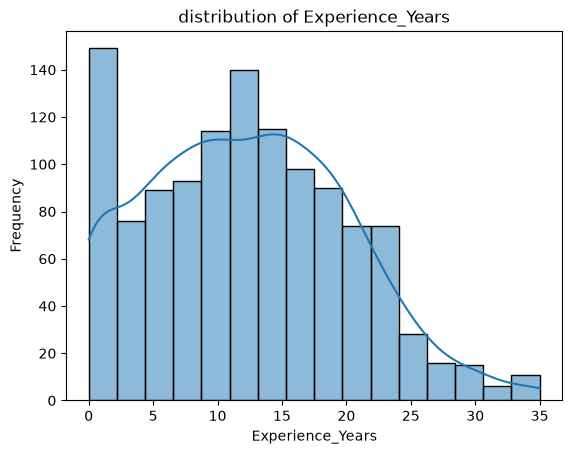

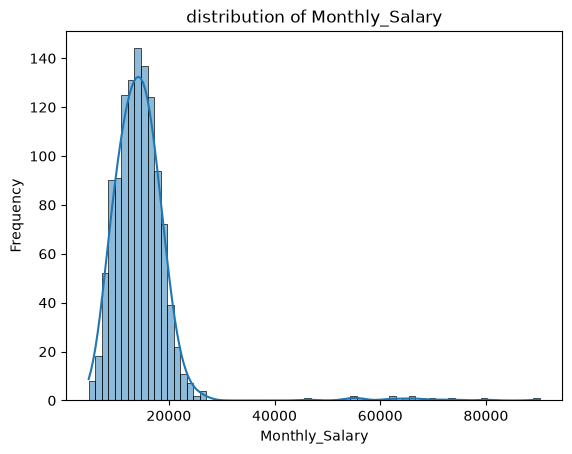

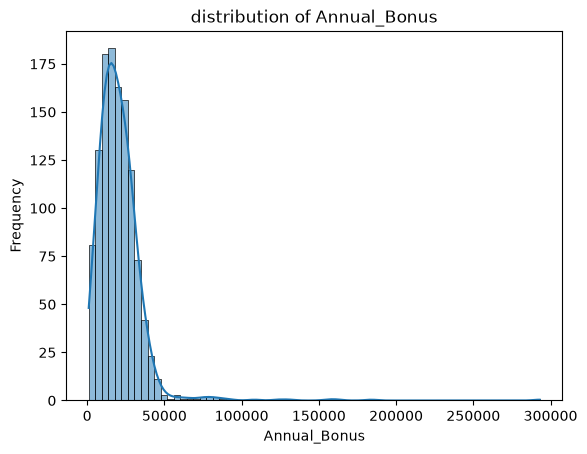

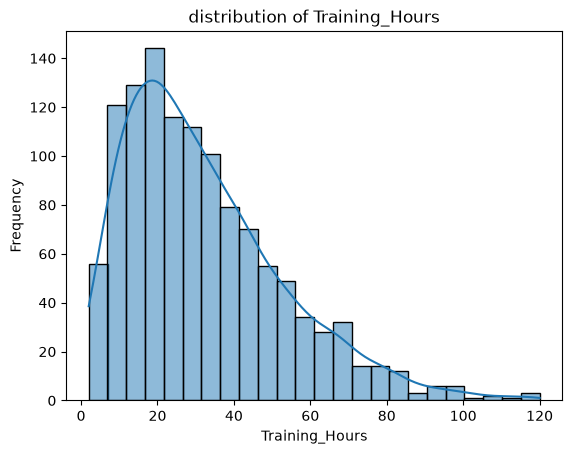

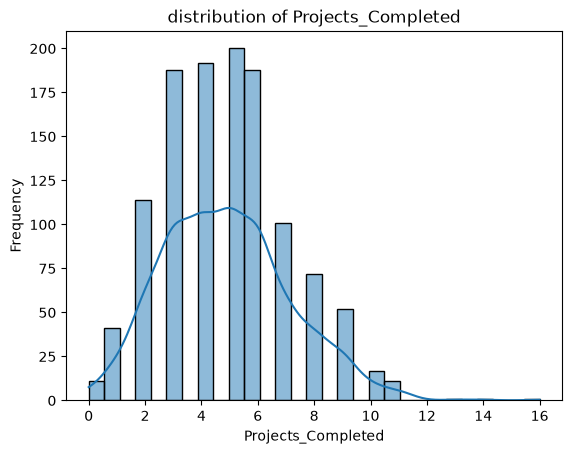

In [ ]:
numerical_cols = [
    "Age",
    "Experience_Years",
    "Monthly_Salary",
    "Annual_Bonus",
    "Training_Hours",
    "Projects_Completed"
]

for value in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[value],kde=True)
    plt.title(f'distribution of {value}')
    plt.xlabel(value)
    plt.ylabel('Frequency')
    plt.show()

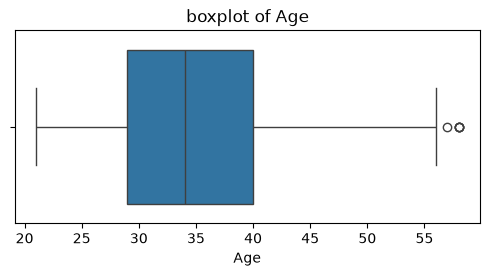

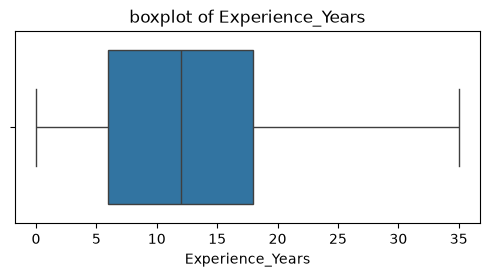

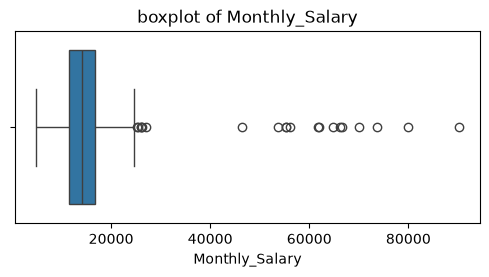

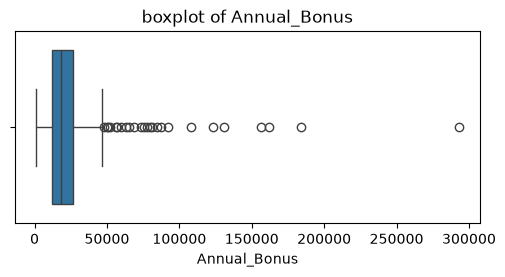

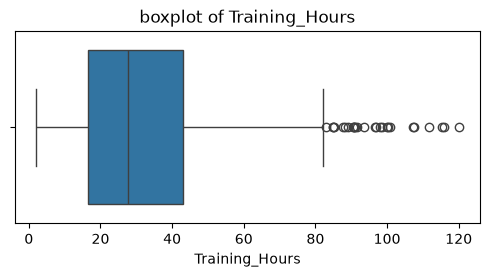

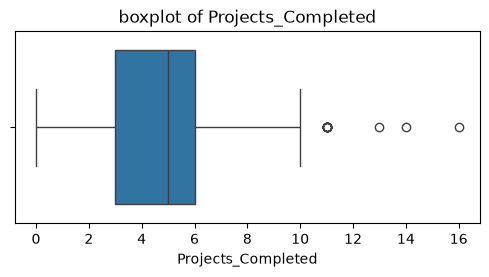

In [ ]:

for cols in numerical_cols:
    plt.figure(figsize=(6,2.5))
    sns.boxplot(x=df[cols])
    plt.title(f'boxplot of {cols}')
    plt.show()

In [ ]:
for col in numerical_cols:
    skew_value = df[col].skew()
    print(f"\nSkewness value of {col}:", skew_value)

    
    



Skewness value of Age: 0.1883889049974149

Skewness value of Experience_Years: 0.30895160623390006

Skewness value of Monthly_Salary: 5.455504227226875

Skewness value of Annual_Bonus: 6.442880808763048

Skewness value of Training_Hours: 1.065045406467709

Skewness value of Projects_Completed: 0.48819680601592597


--- Average Values (Promoted vs Not Promoted) ---
Promotion                     No           Yes
Age                    33.177671     36.988796
Experience_Years       11.048077     15.272472
Monthly_Salary      14044.607645  16315.665938
Annual_Bonus        19342.686835  23398.021039
Training_Hours         29.371049     38.277159
Projects_Completed      4.651079      5.435393


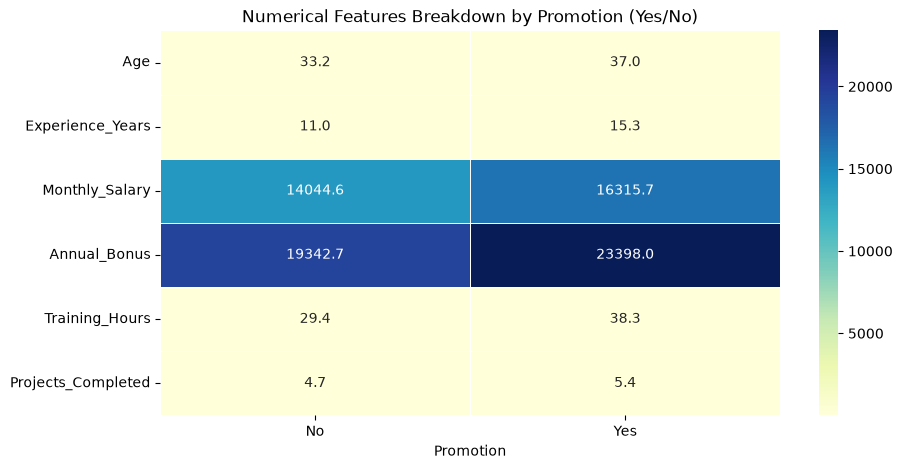

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


numerical_cols = [
    "Age", "Experience_Years", "Monthly_Salary", 
    "Annual_Bonus", "Training_Hours", "Projects_Completed"
]


mean_summary = df.groupby('Promotion')[numerical_cols].mean().T
print("Average Values (Promoted vs Not Promoted) ---")
print(mean_summary)

plt.figure(figsize=(10, 5))
sns.heatmap(mean_summary, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5)
plt.title("Numerical Features Breakdown by Promotion (Yes/No)")
plt.show()

In [ ]:
categorical_cols = [
    "Education",
    "Performance_Score",
    "Job_Satisfaction",
    "Department",
    "Employment_Type",
    "Work_Mode",
    "City"
]

for col in categorical_cols:
    data=df.groupby(col)['Promotion'].value_counts(normalize=True)*100
    print(data)

Education    Promotion
Bachelor     No           70.402802
             Yes          29.597198
High School  No           73.544974
             Yes          26.455026
Master       No           67.536232
             Yes          32.463768
PhD          No           70.114943
             Yes          29.885057
Name: proportion, dtype: float64
Performance_Score  Promotion
Average            No           81.887755
                   Yes          18.112245
Excellent          Yes          50.285714
                   No           49.714286
Good               No           64.825046
                   Yes          35.174954
Poor               No           92.500000
                   Yes           7.500000
Name: proportion, dtype: float64
Job_Satisfaction  Promotion
High              No           70.288248
                  Yes          29.711752
Low               No           71.200000
                  Yes          28.800000
Medium            No           70.796460
                  Yes    

In [ ]:
# Correlation matrix
corr_matrix = df[numerical_cols].corr()

print(corr_matrix)

                         Age  Experience_Years  Monthly_Salary  Annual_Bonus  \
Age                 1.000000          0.928940        0.481640      0.288949   
Experience_Years    0.928940          1.000000        0.492369      0.261101   
Monthly_Salary      0.481640          0.492369        1.000000      0.545065   
Annual_Bonus        0.288949          0.261101        0.545065      1.000000   
Training_Hours      0.013829          0.008379        0.050093      0.027997   
Projects_Completed  0.008174          0.018480       -0.006860      0.019685   

                    Training_Hours  Projects_Completed  
Age                       0.013829            0.008174  
Experience_Years          0.008379            0.018480  
Monthly_Salary            0.050093           -0.006860  
Annual_Bonus              0.027997            0.019685  
Training_Hours            1.000000            0.063560  
Projects_Completed        0.063560            1.000000  


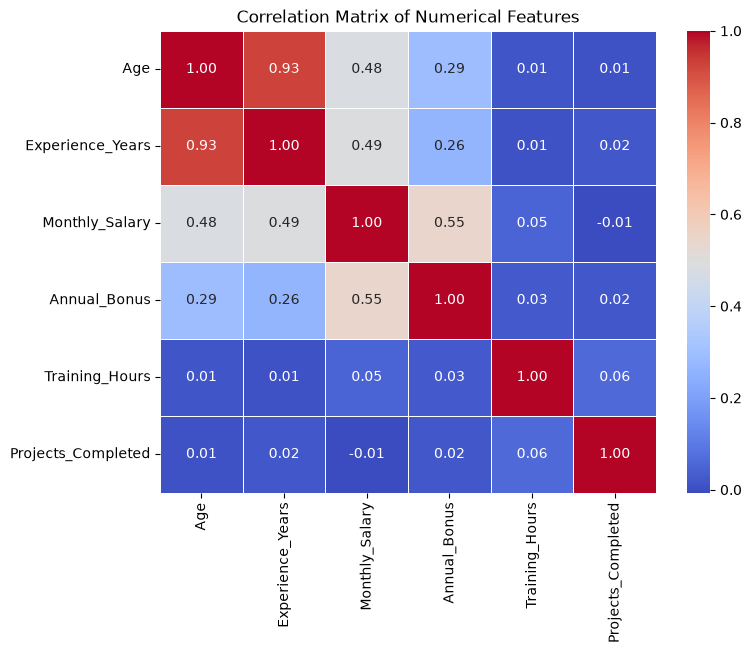

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [164]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class IQRCapper(BaseEstimator, TransformerMixin):

    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        Q1 = np.percentile(X, 25, axis=0)
        Q3 = np.percentile(X, 75, axis=0)

        IQR = Q3 - Q1

        self.upper_bound = Q3 + self.factor * IQR
        self.lower_bound = Q1 - self.factor * IQR

        return self

    def transform(self, X):
        return np.clip(
            X,
            self.lower_bound,
            self.upper_bound
        )

In [165]:
skew_numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),

    ('outlier_capping', IQRCapper()),

    ('transformation', PowerTransformer(method='yeo-johnson')),

    ('scaling', StandardScaler())
])

In [166]:
preprocess_step = ColumnTransformer([
    ('skewed_num_data', skew_numerical_pipeline, skewed_num_cols),

    ('simple_num_data', simple_numerical_pipeline, simple_num_cols),

    ('ordinal_data', ordinal_pipeline, ordinal_cols),

    ('nominal_data', nominal_pipeline, nominal_cols)
])

In [167]:
model = Pipeline([
    ('preprocess', preprocess_step),
    ('lgr', LogisticRegression(random_state=42))
])

In [168]:
model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('lgr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Employee_ID','Age','Experience_Years',...,'Work_Mode','City', 'Promotion_Num']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewed_num_data', ...), ('simple_num_data', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By sp

In [169]:

y_prediction =model.predict(x_test)


In [171]:
from sklearn.metrics import accuracy_score

model_accuracy=accuracy_score(y_test,y_prediction)

print(f'model is {model_accuracy*100} %  Accurate ')

model is 71.38888888888889 %  Accurate 


In [173]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {

   

    'preprocess__skewed_num_data__imputer__strategy':
        ['mean', 'median'],

    'preprocess__skewed_num_data__outlier_capping__factor':
        [1.0, 1.5, 2.0, 3.0],

    'preprocess__skewed_num_data__transformation__method':
        ['yeo-johnson'],

    'preprocess__skewed_num_data__transformation__standardize':
        [True, False],



    'preprocess__simple_num_data__imputer__strategy':
        ['mean', 'median'],

    'preprocess__simple_num_data__scaling':
        [StandardScaler(), 'passthrough'],



    'lgr__C':
        [0.01, 0.1, 1, 10, 100],

    'lgr__solver':
        ['liblinear', 'lbfgs'],

    'lgr__penalty':
        ['l2']
}

In [174]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [175]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [176]:
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 640 candidates, totalling 3200 fits


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lgr__C': [0.01, 0.1, ...], 'lgr__penalty': ['l2'], 'lgr__solver': ['liblinear', 'lbfgs'], 'preprocess__simple_num_data__imputer__strategy': ['mean', 'median'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` paramet

In [179]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'lgr__C': 0.1, 'lgr__penalty': 'l2', 'lgr__solver': 'liblinear', 'preprocess__simple_num_data__imputer__strategy': 'mean', 'preprocess__simple_num_data__scaling': StandardScaler(), 'preprocess__skewed_num_data__imputer__strategy': 'mean', 'preprocess__skewed_num_data__outlier_capping__factor': 1.0, 'preprocess__skewed_num_data__transformation__method': 'yeo-johnson', 'preprocess__skewed_num_data__transformation__standardize': True}


In [178]:
print("Best CV Accuracy:")
print(grid_search.best_score_)

Best CV Accuracy:
0.7488095238095238


In [180]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(x_test)

test_accuracy = accuracy_score(y_test, y_pred)

print("Final Test Accuracy:", test_accuracy)

Final Test Accuracy: 0.7194444444444444


In [194]:
import pickle

with open("../models/employee_promotion_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Model saved successfully!")

Model saved successfully!


In [195]:
# now i will load model to check 
import pickle

with open("../models/employee_promotion_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!


In [183]:
y_pred_loaded = loaded_model.predict(x_test)

print(y_pred_loaded)

['No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No'
 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No'
 'Yes' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No'
 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No'
 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No'
 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No'
 'No' 'No' 'No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No'
 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'Yes' 'Yes' 'No'
 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'Yes'
 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No'
 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No'
 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No'
 'Yes' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'Yes'
 'No' 'No' 'Yes' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'Y

In [184]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_loaded)

print("Loaded Model Accuracy:", accuracy)

Loaded Model Accuracy: 0.7194444444444444


In [185]:
new_employee = pd.DataFrame({
    "Age": [30],
    "Experience_Years": [6],
    "Monthly_Salary": [85000],
    "Annual_Bonus": [12000],
    "Performance_Score": ["Good"],
    "Training_Hours": [40],
    "Projects_Completed": [5],
    "Job_Satisfaction": ["High"],
    "Education": ["Master"],
    "Department": ["IT"],
    "Employment_Type": ["Full-Time"],
    "Work_Mode": ["Hybrid"],
    "City": ["Islamabad"]
})

In [186]:
prediction = loaded_model.predict(new_employee)

print("Prediction:", prediction)

Prediction: ['No']


In [187]:
probability = loaded_model.predict_proba(new_employee)

print("Prediction Probability:", probability)

Prediction Probability: [[0.5928652 0.4071348]]
